SECTION 1: PRELIMINARY DATA INSPECTION

Shape of data       : 9,551 rows × 19 columns
Shape of Country-Code: 15 rows × 2 columns

── Column Data Types ──
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64

── Missing Values ──
                 Missing Count  Missing %
Restaurant Name              1       0.01
Cuisines                     9       0.09

── Duplicate Rows ──
  Full duplicate rows   : 0
  Duplicate Restaurant IDs: 0

── Summar

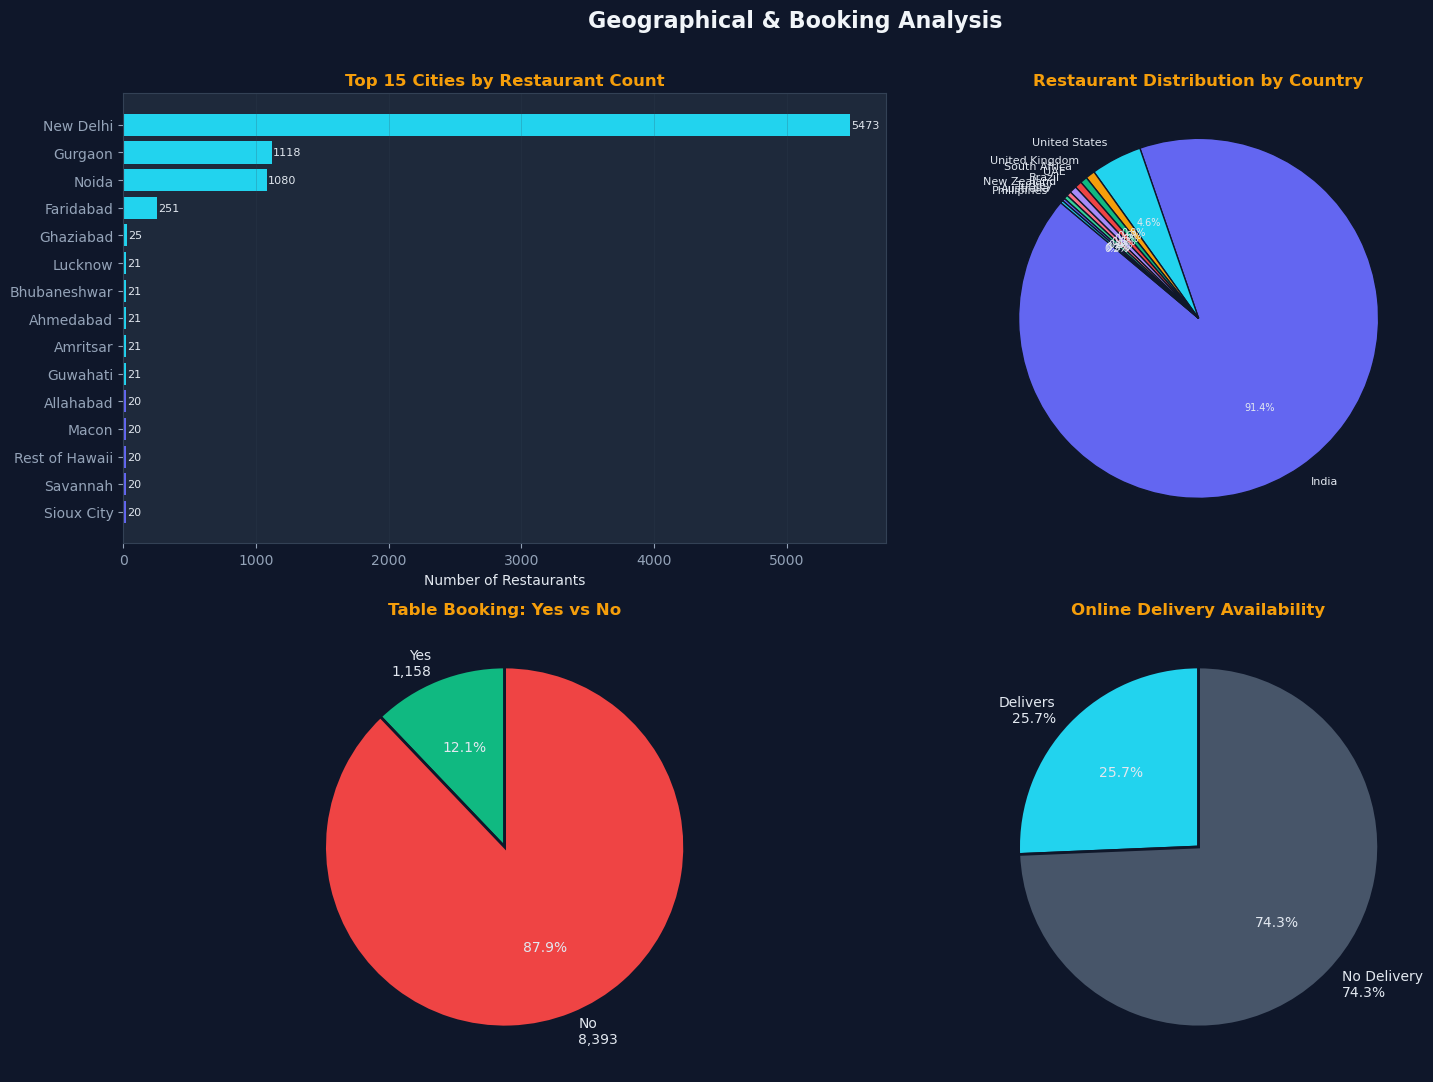

Saved fig1_geo_booking.png


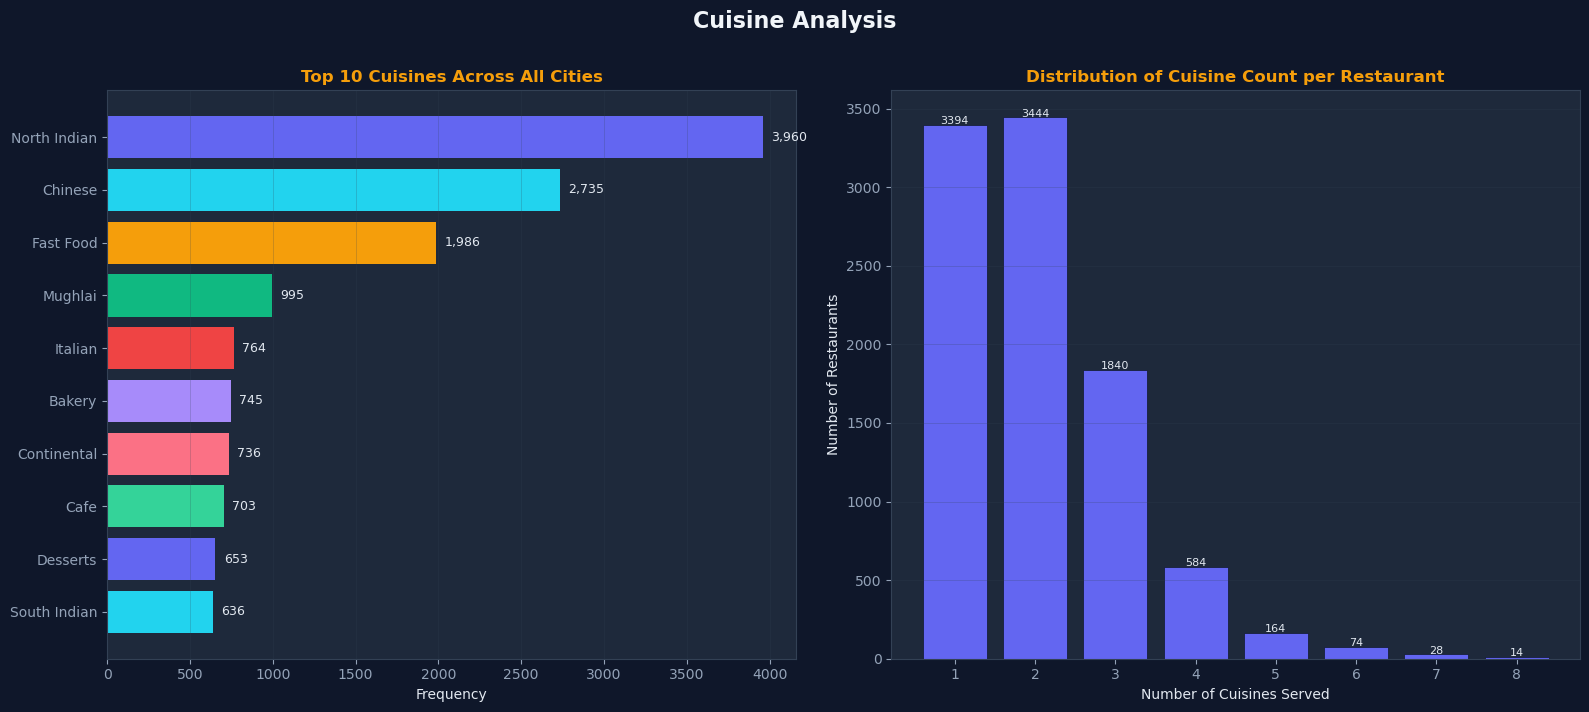

Saved fig2_cuisines.png


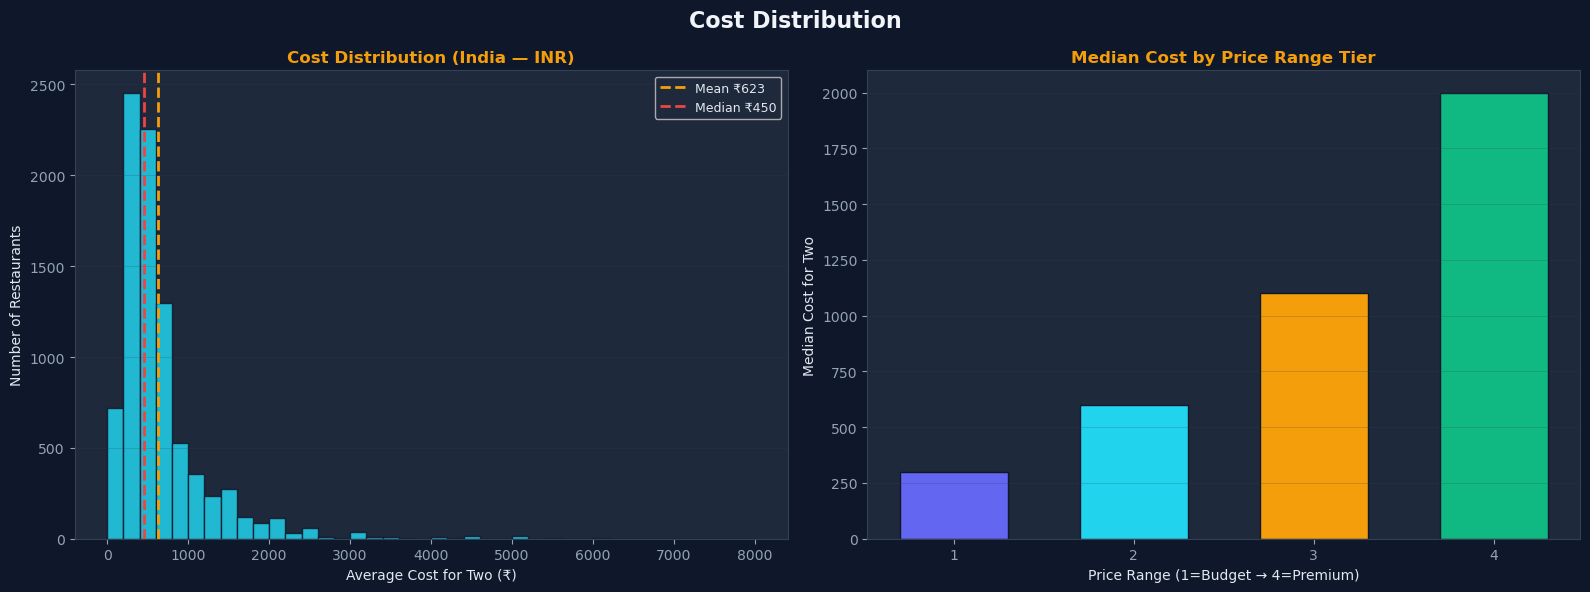

Saved fig3_cost.png


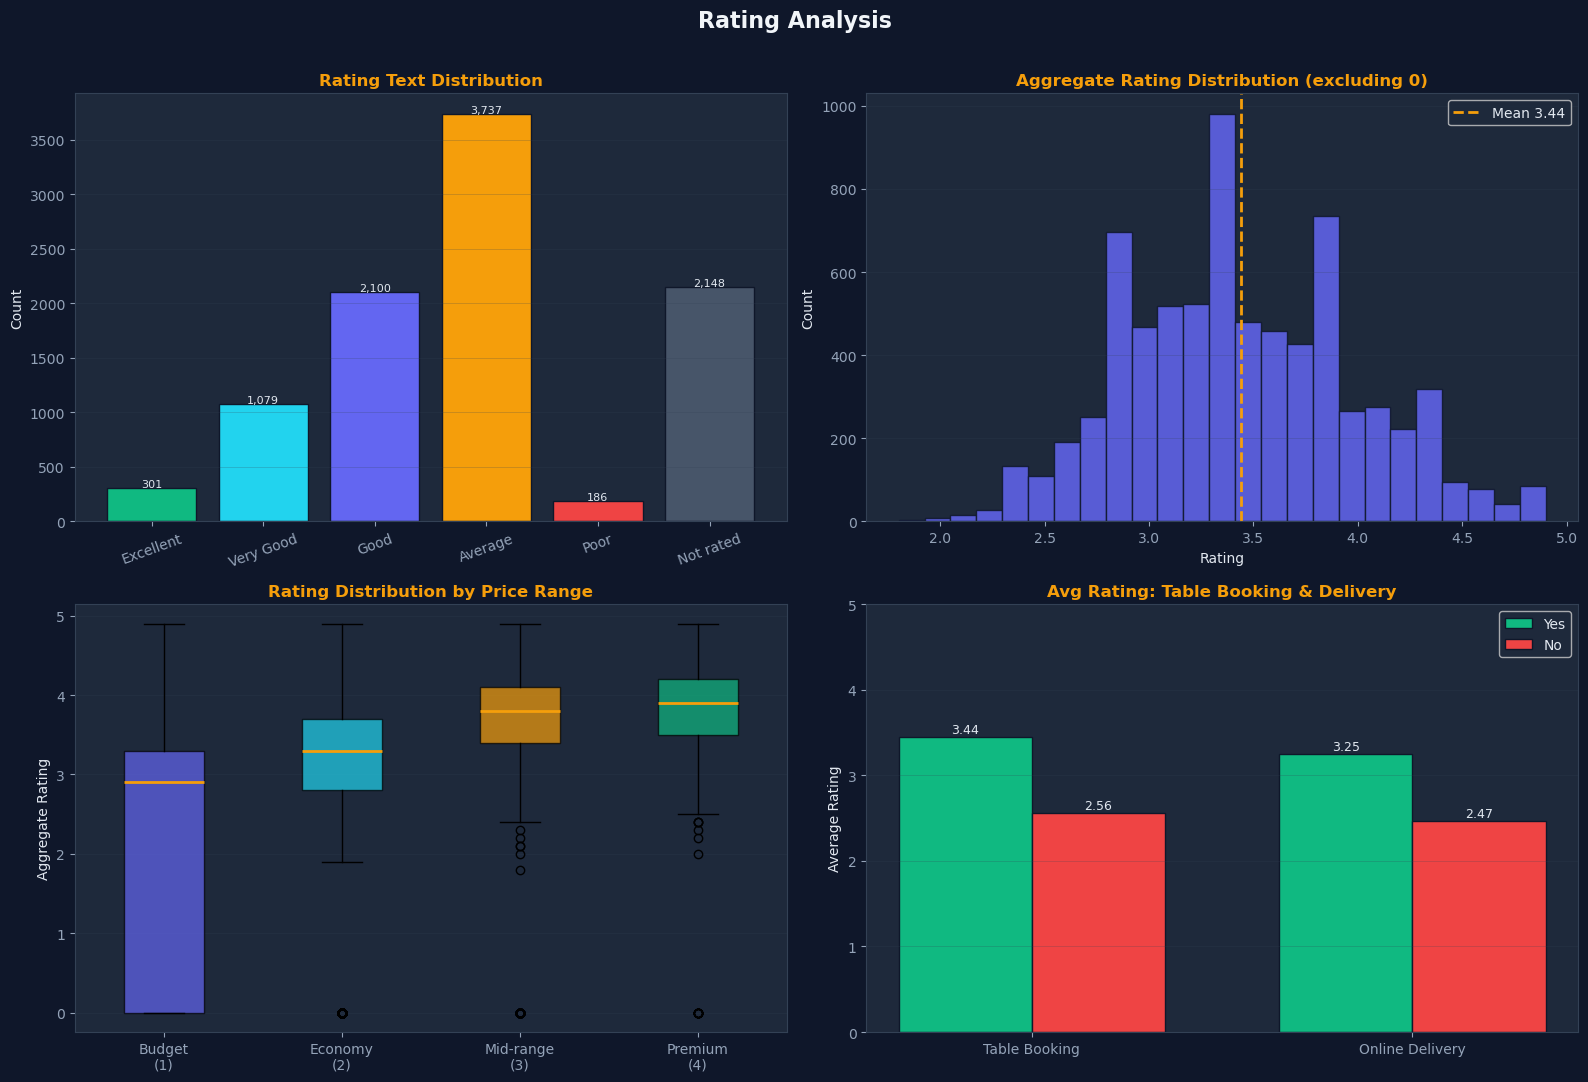

Saved fig4_ratings.png


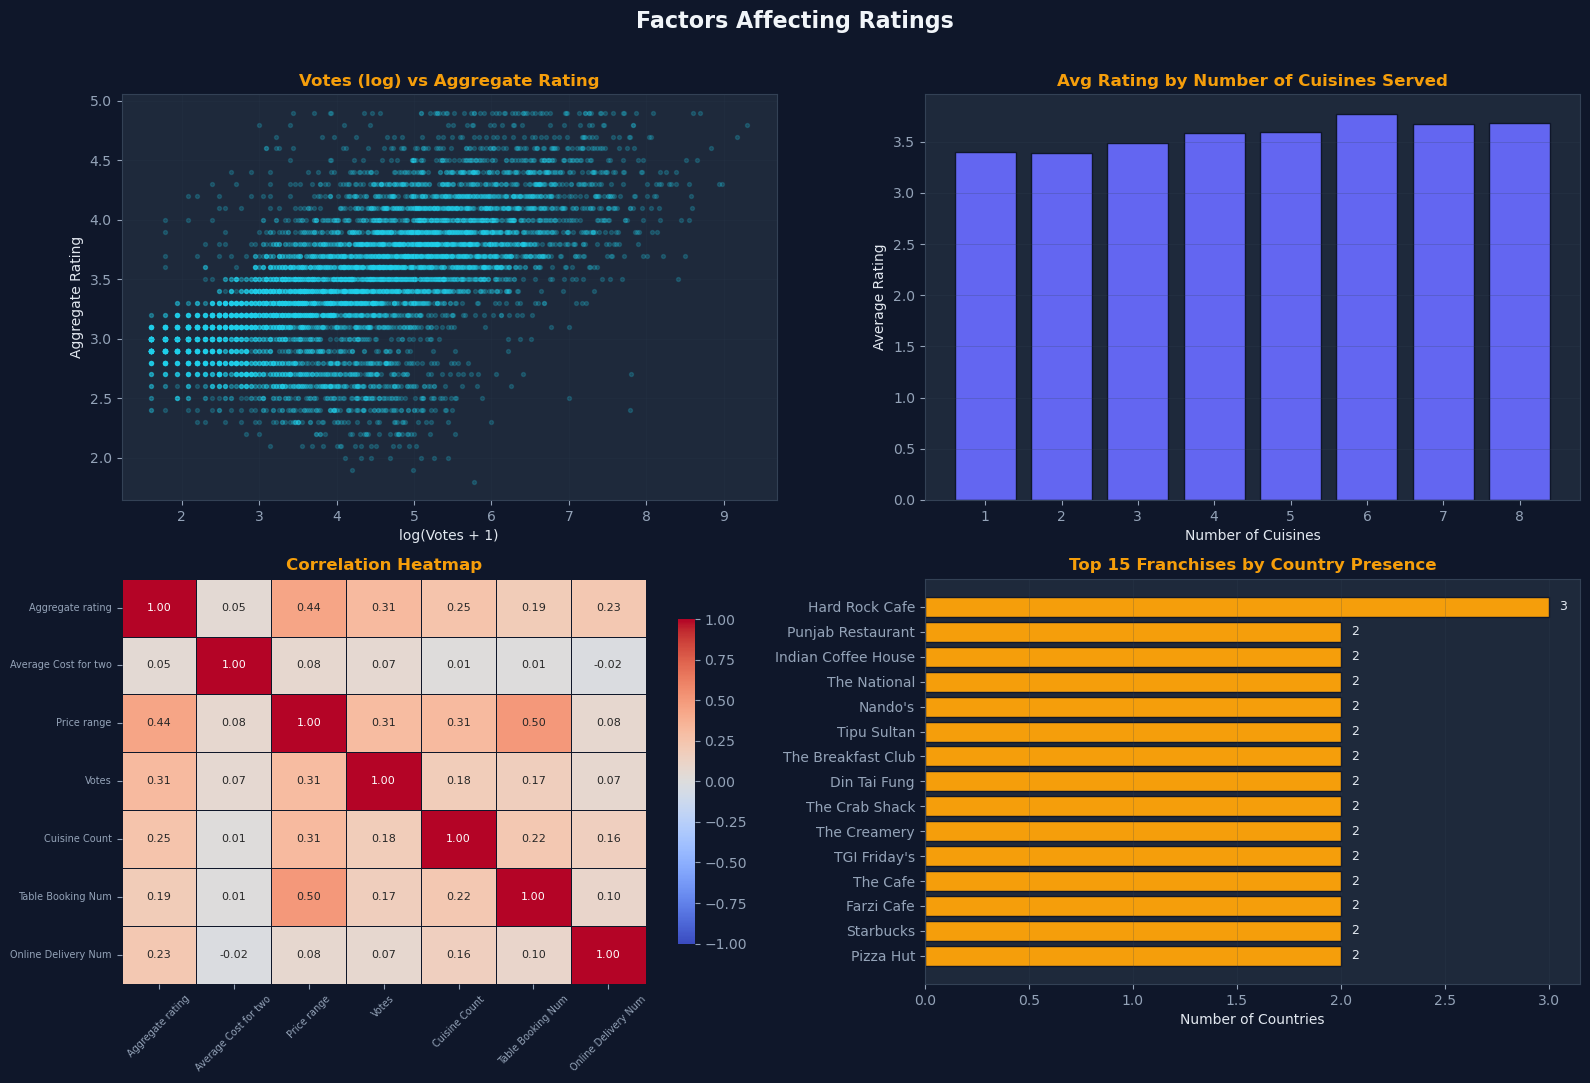

Saved fig5_factors.png

⭐ Star Restaurants (rating≥4.5 & votes≥75th percentile): 261


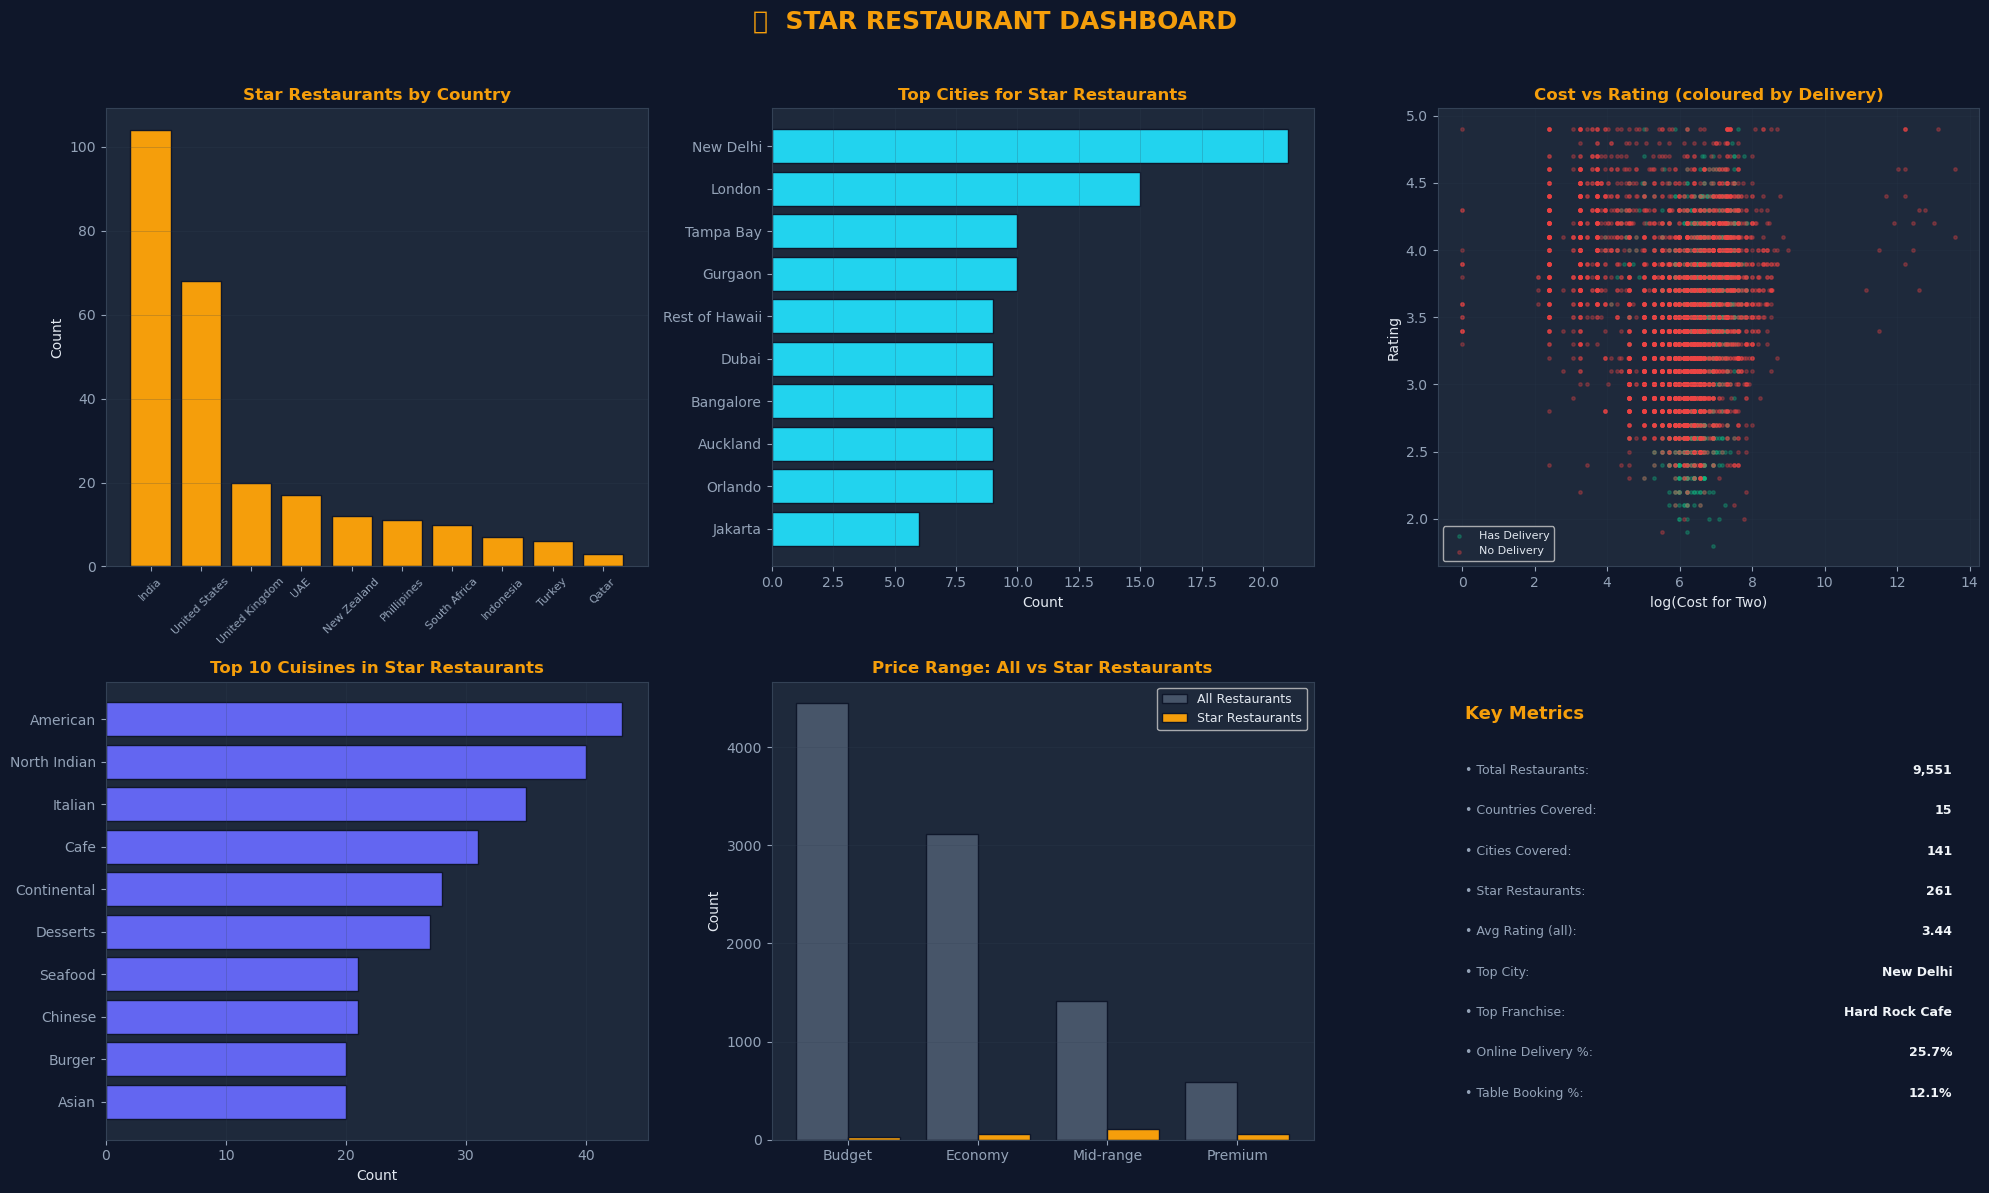

Saved fig6_dashboard.png

✅  All 6 figures saved to /mnt/user-data/outputs/
CSV exported successfully!


In [7]:
"""
Restaurant Consolidator - Comprehensive EDA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

PALETTE   = ['#6366f1','#22d3ee','#f59e0b','#10b981','#ef4444','#a78bfa','#fb7185','#34d399']
GOLD      = '#f59e0b'
TEAL      = '#22d3ee'
INDIGO    = '#6366f1'
GREEN     = '#10b981'
RED       = '#ef4444'

# ─────────────────────────────────────────────
# 1. LOAD & MERGE
# ─────────────────────────────────────────────
data = pd.read_excel(r'C:\Users\sharvari.warudkar\Downloads\1683266696_dataset\Dataset\data.xlsx')
cc   = pd.read_excel(r'C:\Users\sharvari.warudkar\Downloads\1683266696_dataset\Dataset\Country-Code.xlsx')

print("=" * 65)
print("SECTION 1: PRELIMINARY DATA INSPECTION")
print("=" * 65)

print(f"\nShape of data       : {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"Shape of Country-Code: {cc.shape[0]} rows × {cc.shape[1]} columns")

print("\n── Column Data Types ──")
print(data.dtypes.to_string())

print("\n── Missing Values ──")
mv = data.isnull().sum()
mv_pct = (mv / len(data) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct})
print(mv_df[mv_df['Missing Count'] > 0].to_string())

print("\n── Duplicate Rows ──")
dup_full = data.duplicated().sum()
dup_id   = data['Restaurant ID'].duplicated().sum()
print(f"  Full duplicate rows   : {dup_full}")
print(f"  Duplicate Restaurant IDs: {dup_id}")

print("\n── Summary Statistics (numeric columns) ──")
print(data.describe().round(2).to_string())

# ─────────────────────────────────────────────
# 2. CLEAN: remove duplicates & merge country
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 2: DATA CLEANING")
print("=" * 65)

before = len(data)
data.drop_duplicates(inplace=True)
after  = len(data)
print(f"\nRows before dedup: {before:,}   After: {after:,}   Removed: {before-after}")

data = data.merge(cc, on='Country Code', how='left')
print(f"Merged with Country-Code. New shape: {data.shape}")

# ─────────────────────────────────────────────
# 3. GEOGRAPHICAL DISTRIBUTION
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 3: GEOGRAPHICAL DISTRIBUTION")
print("=" * 65)

city_counts = data['City'].value_counts()
print(f"\nTop 5 cities by restaurant count:\n{city_counts.head(5).to_string()}")
print(f"\nBottom 5 cities by restaurant count:\n{city_counts.tail(5).to_string()}")
print(f"\nCity with MAX restaurants: {city_counts.idxmax()} ({city_counts.max():,})")
print(f"City with MIN restaurants: {city_counts.idxmin()} ({city_counts.min():,})")

country_counts = data['Country'].value_counts()
print(f"\nRestaurants by Country:\n{country_counts.to_string()}")

# ─────────────────────────────────────────────
# 4. FRANCHISE NATIONAL PRESENCE
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 4: FRANCHISE NATIONAL PRESENCE")
print("=" * 65)

franchise = (data.groupby('Restaurant Name')['Country']
               .nunique()
               .sort_values(ascending=False))
print(f"\nTop 10 franchises by country presence:\n{franchise.head(10).to_string()}")
print(f"\nFranchise with most national presence: {franchise.idxmax()} ({franchise.max()} countries)")

# ─────────────────────────────────────────────
# 5. TABLE BOOKING RATIO
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 5: TABLE BOOKING RATIO")
print("=" * 65)

tb = data['Has Table booking'].value_counts()
tb_pct = (tb / len(data) * 100).round(2)
print(f"\nTable Booking Counts:\n{tb.to_string()}")
print(f"\nTable Booking Percentages:\n{tb_pct.to_string()}")
ratio_yes = tb.get('Yes', 0)
ratio_no  = tb.get('No', 0)
print(f"\nRatio (Yes : No) = 1 : {ratio_no/ratio_yes:.2f}")

# ─────────────────────────────────────────────
# 6. ONLINE DELIVERY %
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 6: ONLINE DELIVERY")
print("=" * 65)

od = data['Has Online delivery'].value_counts()
od_pct = (od / len(data) * 100).round(2)
print(f"\nOnline Delivery Counts:\n{od.to_string()}")
print(f"\nOnline Delivery %:\n{od_pct.to_string()}")

# ─────────────────────────────────────────────
# 7. VOTES: DELIVER VS NON-DELIVER
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 7: VOTES DIFFERENCE (DELIVERY vs NON-DELIVERY)")
print("=" * 65)

votes_deliver     = data[data['Has Online delivery'] == 'Yes']['Votes'].sum()
votes_no_deliver  = data[data['Has Online delivery'] == 'No']['Votes'].sum()
avg_deliver       = data[data['Has Online delivery'] == 'Yes']['Votes'].mean()
avg_no_deliver    = data[data['Has Online delivery'] == 'No']['Votes'].mean()
print(f"\nTotal votes (delivers)     : {votes_deliver:,}")
print(f"Total votes (no delivery)  : {votes_no_deliver:,}")
print(f"Difference                 : {abs(votes_deliver - votes_no_deliver):,}")
print(f"\nAvg votes (delivers)       : {avg_deliver:.2f}")
print(f"Avg votes (no delivery)    : {avg_no_deliver:.2f}")
print(f"Avg difference             : {abs(avg_deliver - avg_no_deliver):.2f}")

# ─────────────────────────────────────────────
# 8. TOP 10 CUISINES
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 8: TOP 10 CUISINES ACROSS CITIES")
print("=" * 65)

all_cuisines = []
for row in data['Cuisines'].dropna():
    all_cuisines.extend([c.strip() for c in row.split(',')])

cuisine_counts = Counter(all_cuisines)
top10 = pd.Series(cuisine_counts).sort_values(ascending=False).head(10)
print(f"\nTop 10 Cuisines:\n{top10.to_string()}")

# ─────────────────────────────────────────────
# 9. MAX/MIN CUISINES & MOST SERVED PER CITY
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 9: CUISINE COUNT PER RESTAURANT & MOST SERVED PER CITY")
print("=" * 65)

data['Cuisine Count'] = data['Cuisines'].dropna().apply(lambda x: len(x.split(',')))
print(f"\nMax cuisines in one restaurant : {data['Cuisine Count'].max()}")
print(f"Min cuisines in one restaurant : {data['Cuisine Count'].min()}")
print(f"\nRestaurant with max cuisines:")
print(data[data['Cuisine Count'] == data['Cuisine Count'].max()][
    ['Restaurant Name','City','Cuisines']].to_string(index=False))

def most_served_cuisine(group):
    cuiss = []
    for row in group['Cuisines'].dropna():
        cuiss.extend([c.strip() for c in row.split(',')])
    if cuiss:
        return Counter(cuiss).most_common(1)[0][0]
    return 'N/A'

city_top_cuisine = data.groupby('City').apply(most_served_cuisine).reset_index()
city_top_cuisine.columns = ['City', 'Top Cuisine']
print(f"\nMost served cuisine per city (top 15):\n{city_top_cuisine.head(15).to_string(index=False)}")

# ─────────────────────────────────────────────
# 10. COST DISTRIBUTION
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 10: COST DISTRIBUTION")
print("=" * 65)

india_data = data[data['Country'] == 'India']
print(f"\nOverall cost stats (all currencies):")
print(data['Average Cost for two'].describe().round(2).to_string())
print(f"\nIndia-only cost stats (INR):")
print(india_data['Average Cost for two'].describe().round(2).to_string())

print(f"\nCost by Price Range:")
print(data.groupby('Price range')['Average Cost for two']
        .agg(['mean','median','count']).round(2).to_string())

# ─────────────────────────────────────────────
# 11. RATING DISTRIBUTION
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 11: RATING DISTRIBUTION")
print("=" * 65)

print(f"\nRating text distribution:")
print(data['Rating text'].value_counts().to_string())
print(f"\nAggregate rating stats:")
print(data['Aggregate rating'].describe().round(3).to_string())
print(f"\nRating by Table Booking:")
print(data.groupby('Has Table booking')['Aggregate rating'].mean().round(3).to_string())
print(f"\nRating by Online Delivery:")
print(data.groupby('Has Online delivery')['Aggregate rating'].mean().round(3).to_string())
print(f"\nRating by Price Range:")
print(data.groupby('Price range')['Aggregate rating'].mean().round(3).to_string())

# ─────────────────────────────────────────────
# 12. FACTORS AFFECTING RATINGS (correlation)
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 12: FACTORS AFFECTING RATINGS")
print("=" * 65)

data['Table Booking Num']   = (data['Has Table booking']   == 'Yes').astype(int)
data['Online Delivery Num'] = (data['Has Online delivery'] == 'Yes').astype(int)

corr_features = ['Aggregate rating','Average Cost for two','Price range',
                 'Votes','Cuisine Count','Table Booking Num','Online Delivery Num']
corr_df = data[corr_features].dropna()
corr_matrix = corr_df.corr()
print("\nCorrelation with Aggregate Rating:")
print(corr_matrix['Aggregate rating'].sort_values(ascending=False).round(4).to_string())

print("\n\n✅  All analysis complete — generating visualizations...\n")

# ═══════════════════════════════════════════════════════════════
#  VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════

def add_value_labels(ax, fmt='{:.0f}', fontsize=8, color='#e2e8f0', pad=3):
    for p in ax.patches:
        val = p.get_height() if p.get_height() != 0 else p.get_width()
        if val > 0:
            ax.annotate(fmt.format(val),
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=fontsize,
                        color=color, xytext=(0, pad), textcoords='offset points')

# ─── FIG 1: Geographic & Booking overview ───────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(16, 11))
fig1.patch.set_facecolor('#0f172a')
fig1.suptitle('Geographical & Booking Analysis', fontsize=16,
               color='#f1f5f9', fontweight='bold', y=0.98)

# (1,1) Top 15 cities
ax = axes[0, 0]
top_cities = city_counts.head(15)
bars = ax.barh(top_cities.index[::-1], top_cities.values[::-1],
               color=[INDIGO]*5 + [TEAL]*10)
ax.set_title('Top 15 Cities by Restaurant Count', color=GOLD, fontweight='bold')
ax.set_xlabel('Number of Restaurants')
for i, v in enumerate(top_cities.values[::-1]):
    ax.text(v + 10, i, str(v), va='center', fontsize=8, color='#e2e8f0')
ax.grid(axis='x', alpha=0.3)

# (1,2) Country distribution
ax = axes[0, 1]
top_countries = country_counts.head(10)
colors_c = [PALETTE[i % len(PALETTE)] for i in range(len(top_countries))]
wedges, texts, autotexts = ax.pie(
    top_countries.values, labels=top_countries.index, autopct='%1.1f%%',
    colors=colors_c, startangle=140, textprops={'fontsize': 8, 'color': '#e2e8f0'},
    wedgeprops={'linewidth': 1, 'edgecolor': '#0f172a'})
for at in autotexts:
    at.set_fontsize(7)
ax.set_title('Restaurant Distribution by Country', color=GOLD, fontweight='bold')

# (2,1) Table booking ratio
ax = axes[1, 0]
tb_vals = [tb.get('Yes', 0), tb.get('No', 0)]
tb_labels = [f"Yes\n{tb_vals[0]:,}", f"No\n{tb_vals[1]:,}"]
wedges, texts, autotexts = ax.pie(
    tb_vals, labels=tb_labels, autopct='%1.1f%%',
    colors=[GREEN, RED], startangle=90,
    textprops={'fontsize': 10, 'color': '#e2e8f0'},
    wedgeprops={'linewidth': 2, 'edgecolor': '#0f172a'})
ax.set_title('Table Booking: Yes vs No', color=GOLD, fontweight='bold')

# (2,2) Online delivery %
ax = axes[1, 1]
od_vals = [od.get('Yes', 0), od.get('No', 0)]
od_labels = [f"Delivers\n{od_pct.get('Yes',0):.1f}%", f"No Delivery\n{od_pct.get('No',0):.1f}%"]
ax.pie(od_vals, labels=od_labels, autopct='%1.1f%%',
       colors=[TEAL, '#475569'], startangle=90,
       textprops={'fontsize': 10, 'color': '#e2e8f0'},
       wedgeprops={'linewidth': 2, 'edgecolor': '#0f172a'})
ax.set_title('Online Delivery Availability', color=GOLD, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig1_geo_booking.png', dpi=150, bbox_inches='tight', 
            facecolor='#0f172a')
plt.close()
print("Saved fig1_geo_booking.png")

# ─── FIG 2: Cuisines ────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 7))
fig2.patch.set_facecolor('#0f172a')
fig2.suptitle('Cuisine Analysis', fontsize=16, color='#f1f5f9',
               fontweight='bold', y=1.01)

# Top 10 cuisines
ax = axes[0]
colors_top = [PALETTE[i % len(PALETTE)] for i in range(10)]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors_top[::-1])
ax.set_title('Top 10 Cuisines Across All Cities', color=GOLD, fontweight='bold')
ax.set_xlabel('Frequency')
for i, v in enumerate(top10.values[::-1]):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9, color='#e2e8f0')
ax.grid(axis='x', alpha=0.3)

# Cuisine count distribution
ax = axes[1]
cc_dist = data['Cuisine Count'].value_counts().sort_index()
ax.bar(cc_dist.index, cc_dist.values, color=INDIGO, edgecolor='#0f172a', linewidth=0.5)
ax.set_title('Distribution of Cuisine Count per Restaurant', color=GOLD, fontweight='bold')
ax.set_xlabel('Number of Cuisines Served')
ax.set_ylabel('Number of Restaurants')
ax.grid(axis='y', alpha=0.3)
for x, y in zip(cc_dist.index, cc_dist.values):
    ax.text(x, y + 5, str(y), ha='center', fontsize=8, color='#e2e8f0')

plt.tight_layout()
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig2_cuisines.png', dpi=150, bbox_inches='tight', 
            facecolor='#0f172a')
plt.close()
print("Saved fig2_cuisines.png")

# ─── FIG 3: Cost distribution ───────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#0f172a')
fig3.suptitle('Cost Distribution', fontsize=16, color='#f1f5f9', fontweight='bold')

# India INR histogram
ax = axes[0]
india_cost = india_data['Average Cost for two']
ax.hist(india_cost, bins=40, color=TEAL, edgecolor='#0f172a', alpha=0.85)
ax.axvline(india_cost.mean(), color=GOLD, linestyle='--', linewidth=2,
           label=f'Mean ₹{india_cost.mean():.0f}')
ax.axvline(india_cost.median(), color=RED, linestyle='--', linewidth=2,
           label=f'Median ₹{india_cost.median():.0f}')
ax.set_title('Cost Distribution (India — INR)', color=GOLD, fontweight='bold')
ax.set_xlabel('Average Cost for Two (₹)')
ax.set_ylabel('Number of Restaurants')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Avg cost by price range
ax = axes[1]
pr_cost = data.groupby('Price range')['Average Cost for two'].median()
bars = ax.bar(pr_cost.index, pr_cost.values,
              color=[PALETTE[i] for i in range(len(pr_cost))],
              edgecolor='#0f172a', width=0.6)
ax.set_title('Median Cost by Price Range Tier', color=GOLD, fontweight='bold')
ax.set_xlabel('Price Range (1=Budget → 4=Premium)')
ax.set_ylabel('Median Cost for Two')
ax.set_xticks([1, 2, 3, 4])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig3_cost.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.close()
print("Saved fig3_cost.png")

# ─── FIG 4: Ratings ─────────────────────────────────────────────
fig4, axes = plt.subplots(2, 2, figsize=(16, 11))
fig4.patch.set_facecolor('#0f172a')
fig4.suptitle('Rating Analysis', fontsize=16, color='#f1f5f9', fontweight='bold', y=0.98)

# Rating text distribution
ax = axes[0, 0]
rt_order = ['Excellent','Very Good','Good','Average','Poor','Not rated']
rt_vals   = [data['Rating text'].value_counts().get(r, 0) for r in rt_order]
rt_colors = [GREEN, TEAL, INDIGO, GOLD, RED, '#475569']
bars = ax.bar(rt_order, rt_vals, color=rt_colors, edgecolor='#0f172a')
ax.set_title('Rating Text Distribution', color=GOLD, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
for p in bars:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+10,
            f'{int(p.get_height()):,}', ha='center', fontsize=8, color='#e2e8f0')
ax.grid(axis='y', alpha=0.3)

# Aggregate rating histogram
ax = axes[0, 1]
rated = data[data['Aggregate rating'] > 0]['Aggregate rating']
ax.hist(rated, bins=25, color=INDIGO, edgecolor='#0f172a', alpha=0.85)
ax.axvline(rated.mean(), color=GOLD, linestyle='--', linewidth=2,
           label=f'Mean {rated.mean():.2f}')
ax.set_title('Aggregate Rating Distribution (excluding 0)', color=GOLD, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Rating vs Price Range (box)
ax = axes[1, 0]
groups = [data[data['Price range'] == p]['Aggregate rating'].dropna().values
          for p in [1, 2, 3, 4]]
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color=GOLD, linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Budget\n(1)', 'Economy\n(2)', 'Mid-range\n(3)', 'Premium\n(4)'])
ax.set_title('Rating Distribution by Price Range', color=GOLD, fontweight='bold')
ax.set_ylabel('Aggregate Rating')
ax.grid(axis='y', alpha=0.3)

# Rating vs Delivery & Table Booking (grouped bar)
ax = axes[1, 1]
groups_data = {
    'Table Booking': data.groupby('Has Table booking')['Aggregate rating'].mean(),
    'Online Delivery': data.groupby('Has Online delivery')['Aggregate rating'].mean(),
}
x = np.arange(2)
w = 0.35
bars1 = ax.bar(x - w/2,
               [groups_data['Table Booking']['Yes'], groups_data['Online Delivery']['Yes']],
               w, label='Yes', color=GREEN, edgecolor='#0f172a')
bars2 = ax.bar(x + w/2,
               [groups_data['Table Booking']['No'], groups_data['Online Delivery']['No']],
               w, label='No', color=RED, edgecolor='#0f172a')
ax.set_xticks(x)
ax.set_xticklabels(['Table Booking', 'Online Delivery'])
ax.set_ylabel('Average Rating')
ax.set_title('Avg Rating: Table Booking & Delivery', color=GOLD, fontweight='bold')
ax.legend()
ax.set_ylim(0, 5)
ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color='#e2e8f0')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig4_ratings.png', dpi=150, bbox_inches='tight', 
            facecolor='#0f172a')
plt.close()
print("Saved fig4_ratings.png")

# ─── FIG 5: Factors affecting ratings ──────────────────────────
fig5, axes = plt.subplots(2, 2, figsize=(16, 11))
fig5.patch.set_facecolor('#0f172a')
fig5.suptitle('Factors Affecting Ratings', fontsize=16, color='#f1f5f9',
               fontweight='bold', y=0.98)

plot_data = data[data['Aggregate rating'] > 0].copy()

# Votes vs Rating scatter
ax = axes[0, 0]
ax.scatter(np.log1p(plot_data['Votes']), plot_data['Aggregate rating'],
           alpha=0.2, s=8, c=TEAL)
ax.set_title('Votes (log) vs Aggregate Rating', color=GOLD, fontweight='bold')
ax.set_xlabel('log(Votes + 1)')
ax.set_ylabel('Aggregate Rating')
ax.grid(alpha=0.2)

# Cuisine count vs rating
ax = axes[0, 1]
cc_rating = plot_data.groupby('Cuisine Count')['Aggregate rating'].mean()
ax.bar(cc_rating.index, cc_rating.values, color=INDIGO, edgecolor='#0f172a')
ax.set_title('Avg Rating by Number of Cuisines Served', color=GOLD, fontweight='bold')
ax.set_xlabel('Number of Cuisines')
ax.set_ylabel('Average Rating')
ax.grid(axis='y', alpha=0.3)

# Correlation heatmap
ax = axes[1, 0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, linecolor='#0f172a',
            annot_kws={'size': 8}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', color=GOLD, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

# Top franchise presence
ax = axes[1, 1]
top_franchise = franchise.head(15)
ax.barh(top_franchise.index[::-1], top_franchise.values[::-1], color=GOLD, edgecolor='#0f172a')
ax.set_title('Top 15 Franchises by Country Presence', color=GOLD, fontweight='bold')
ax.set_xlabel('Number of Countries')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(top_franchise.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9, color='#e2e8f0')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig5_factors.png', dpi=150, bbox_inches='tight', 
            facecolor='#0f172a')
plt.close()
print("Saved fig5_factors.png")

# ─── FIG 6: Dashboard / Star Restaurant ─────────────────────────
fig6, axes = plt.subplots(2, 3, figsize=(20, 12))
fig6.patch.set_facecolor('#0f172a')
fig6.suptitle('⭐  STAR RESTAURANT DASHBOARD', fontsize=18,
               color=GOLD, fontweight='bold', y=0.99)

# Star restaurants: highly rated + many votes
star = data[(data['Aggregate rating'] >= 4.5) &
            (data['Votes'] >= data['Votes'].quantile(0.75))].copy()
print(f"\n⭐ Star Restaurants (rating≥4.5 & votes≥75th percentile): {len(star)}")

# (0,0) Star count by country
ax = axes[0, 0]
sc = star['Country'].value_counts().head(10)
ax.bar(sc.index, sc.values, color=GOLD, edgecolor='#0f172a')
ax.set_title('Star Restaurants by Country', color=GOLD, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)

# (0,1) Star restaurants by city (top 10)
ax = axes[0, 1]
sc_city = star['City'].value_counts().head(10)
ax.barh(sc_city.index[::-1], sc_city.values[::-1], color=TEAL, edgecolor='#0f172a')
ax.set_title('Top Cities for Star Restaurants', color=GOLD, fontweight='bold')
ax.set_xlabel('Count')
ax.grid(axis='x', alpha=0.3)

# (0,2) Rating scatter: cost vs rating coloured by delivery
ax = axes[0, 2]
for val, color, label in [('Yes', GREEN, 'Has Delivery'), ('No', RED, 'No Delivery')]:
    sub = plot_data[plot_data['Has Online delivery'] == val]
    ax.scatter(np.log1p(sub['Average Cost for two']), sub['Aggregate rating'],
               alpha=0.3, s=6, c=color, label=label)
ax.set_title('Cost vs Rating (coloured by Delivery)', color=GOLD, fontweight='bold')
ax.set_xlabel('log(Cost for Two)')
ax.set_ylabel('Rating')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# (1,0) Top 10 cuisines of star restaurants
ax = axes[1, 0]
star_cuiss = []
for row in star['Cuisines'].dropna():
    star_cuiss.extend([c.strip() for c in row.split(',')])
sc_top = pd.Series(Counter(star_cuiss)).sort_values(ascending=False).head(10)
ax.barh(sc_top.index[::-1], sc_top.values[::-1], color=INDIGO, edgecolor='#0f172a')
ax.set_title('Top 10 Cuisines in Star Restaurants', color=GOLD, fontweight='bold')
ax.set_xlabel('Count')
ax.grid(axis='x', alpha=0.3)

# (1,1) Price range distribution of star vs all
ax = axes[1, 1]
pr_all  = data['Price range'].value_counts().sort_index()
pr_star = star['Price range'].value_counts().sort_index()
x = np.arange(1, 5)
w = 0.4
ax.bar(x - w/2, [pr_all.get(i,0) for i in x], w,
       label='All Restaurants', color='#475569', edgecolor='#0f172a')
ax.bar(x + w/2, [pr_star.get(i,0) for i in x], w,
       label='Star Restaurants', color=GOLD, edgecolor='#0f172a')
ax.set_xticks(x)
ax.set_xticklabels(['Budget','Economy','Mid-range','Premium'])
ax.set_title('Price Range: All vs Star Restaurants', color=GOLD, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# (1,2) KPI text summary
ax = axes[1, 2]
ax.set_facecolor('#1e293b')
ax.axis('off')
kpis = [
    ("Total Restaurants",   f"{len(data):,}"),
    ("Countries Covered",   f"{data['Country'].nunique()}"),
    ("Cities Covered",      f"{data['City'].nunique()}"),
    ("Star Restaurants",    f"{len(star):,}"),
    ("Avg Rating (all)",    f"{data[data['Aggregate rating']>0]['Aggregate rating'].mean():.2f}"),
    ("Top City",            city_counts.idxmax()),
    ("Top Franchise",       franchise.idxmax()),
    ("Online Delivery %",   f"{od_pct.get('Yes',0):.1f}%"),
    ("Table Booking %",     f"{tb_pct.get('Yes',0):.1f}%"),
]
ax.text(0.05, 0.95, "Key Metrics", transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=GOLD, va='top')
for i, (label, val) in enumerate(kpis):
    y = 0.82 - i * 0.088
    ax.text(0.05, y, f"• {label}:", transform=ax.transAxes,
            fontsize=9, color='#94a3b8', va='top')
    ax.text(0.95, y, val, transform=ax.transAxes,
            fontsize=9, color='#f1f5f9', va='top', ha='right', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()     
plt.savefig(r'C:\Users\sharvari.warudkar\Downloads\fig6_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.close()
print("Saved fig6_dashboard.png")

print("\n✅  All 6 figures saved to /mnt/user-data/outputs/")

# Export cleaned merged data for Tableau
data.to_csv(r'C:\Users\sharvari.warudkar\Downloads\restaurant_clean.csv', index=False)
print("CSV exported successfully!")
